In [2]:
import os
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import timm
import torch
import torch.nn as nn
import torch.optim as optim
from IPython.display import display
from PIL import Image, ImageDraw, ImageFont
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms
from transformers import (
    Trainer,
    TrainingArguments,
    YolosForObjectDetection,
    YolosImageProcessor,
)

In [3]:
# Add path to the dataset
path = "Dataset"
image_dir = "Dataset/images"
file = "Dataset/labels_train.csv"
print("Path to dataset files:", path)
newData = pd.read_csv(file)

Path to dataset files: Dataset


In [4]:
# CUDA Check
cuda_available = torch.cuda.is_available()

if cuda_available:
    print("CUDA available, GPU Is Available")
    print("CUDA Version: ", torch.version.cuda)
    print("CUDA Device: ", torch.cuda.current_device())
else:
    print("CUDA not available, using CPU")

devices = [torch.cuda.device(i) for i in range(torch.cuda.device_count())]
for device in devices:
    print(torch.cuda.get_device_name(device))

CUDA available, GPU Is Available
CUDA Version:  13.0
CUDA Device:  0
NVIDIA GeForce RTX 4090 Laptop GPU


Description of the dataset: 
                 xmin           xmax           ymin           ymax  \
count  132406.000000  132406.000000  132406.000000  132406.000000   
mean      202.112223     235.400118     133.525376     162.240148   
std       114.647213     116.401491      20.508451      28.585448   
min         0.000000       3.000000       0.000000       0.000000   
25%       118.000000     150.000000     131.000000     152.000000   
50%       200.000000     224.000000     139.000000     160.000000   
75%       280.000000     312.000000     143.000000     171.000000   
max       475.000000     479.000000     275.000000     299.000000   

            class_id  
count  132406.000000  
mean        1.624692  
std         1.269443  
min         1.000000  
25%         1.000000  
50%         1.000000  
75%         1.000000  
max         5.000000   

Null values in the dataset:
 frame       0
xmin        0
xmax        0
ymin        0
ymax        0
class_id    0
dtype: int64 

Dataset loa

,frame,xmin,xmax,ymin,ymax,class_id
7573,1478020644712955174.jpg,232,238,108,118,5
7574,1478020644712955174.jpg,232,238,108,118,5
8238,1478020832210646675.jpg,195,205,89,103,5
8239,1478020832210646675.jpg,195,205,89,103,5
9692,1478020944220115330.jpg,200,212,142,153,1
9693,1478020944220115330.jpg,200,212,142,153,1
12633,1478021875081281646.jpg,158,176,138,152,1
12634,1478021875081281646.jpg,158,176,138,152,1
13937,1478731898295473636.jpg,167,174,100,114,5
13938,1478731898295473636.jpg,167,174,100,114,5



Dataset now has 132386 rows after removing duplicates.


No missing values found.

Found 2 rows with invalid bounding box dimensions.
Showing invalid rows:


,frame,xmin,xmax,ymin,ymax,class_id
102729,1479503436307292305.jpg,270,281,0,0,1
127666,1479505804469947973.jpg,188,195,0,0,1


Removing rows with invalid bounding box dimensions.
Dataset now has 132384 rows after removing invalid bounding boxes.

Analyzing class distribution...
Class distribution:
class_id
1    101302
5     12691
3     10636
2      6313
4      1442
Name: count, dtype: int64


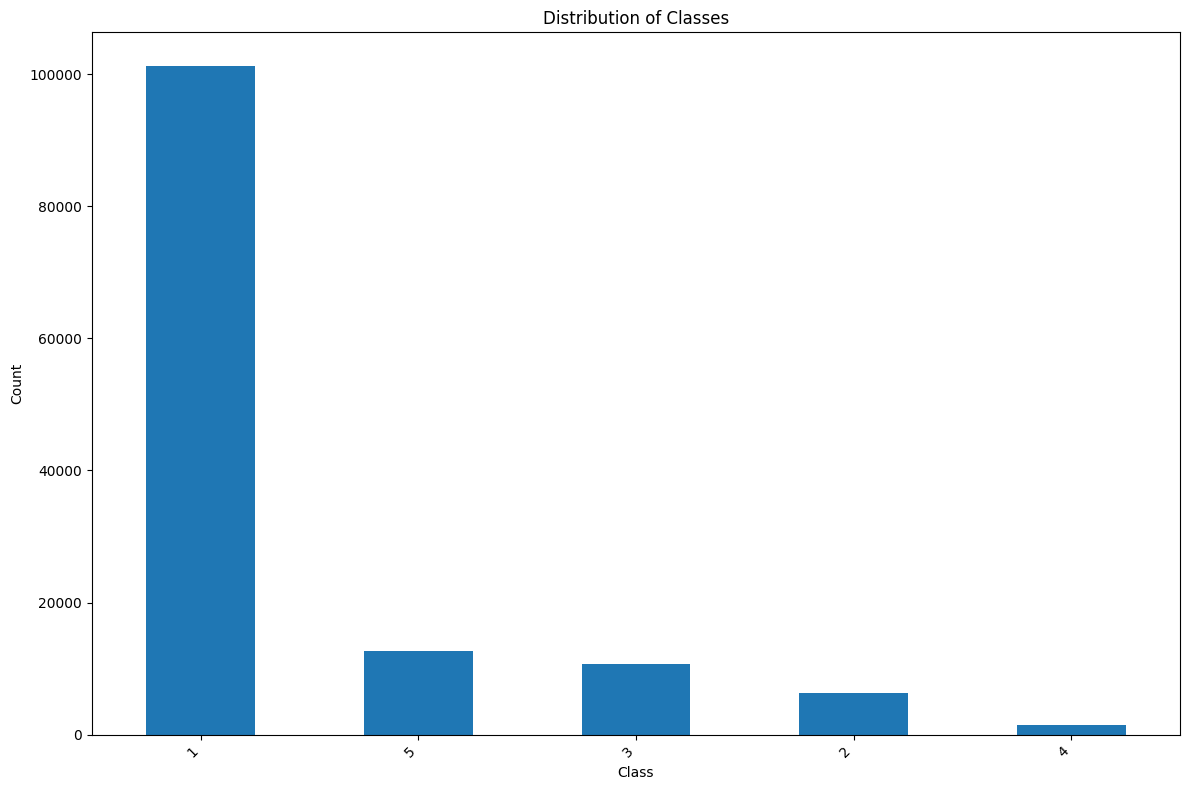


Potential class imbalance detected. Some classes have significantly fewer examples.
Consider data augmentation or re-sampling techniques during training.


In [5]:
# EDA
print("Description of the dataset: \n", newData.describe(), "\n")
print("Null values in the dataset:\n", newData.isnull().sum(), "\n")

# Check for empty dataset
if newData.empty:
    print("Dataset is empty. No data to process or train.")
else:
    print("Dataset loaded successfully with", len(newData), "rows.")


# Check for redundancy (duplicate rows)
# Use keep=False to mark all duplicate occurrences as True
duplicate_mask = newData.duplicated(keep=False)
duplicate_count = duplicate_mask.sum()

if duplicate_count > 0:
    print("Found", duplicate_count, "duplicate rows. Removing duplicates.")
    print("Showing duplicate rows:\n")
    # Show data duplicates
    display(newData[duplicate_mask])  # Use display for better formatting
    # Remove duplicates
    newData.drop_duplicates(inplace=True)
    print("\nDataset now has", len(newData), "rows after removing duplicates.\n")
else:
    print("No duplicate rows found.")

# Check for missing values
missing_values = newData.isnull().sum()
if missing_values.sum() > 0:
    print("\nMissing values per column:")
    print(missing_values[missing_values > 0])
else:
    print("\nNo missing values found.")

# Data Cleaning and Preprocessing
# Check for invalid bounding box dimensions (width or height <= 0)
invalid_bbox_mask = (newData["xmax"] <= newData["xmin"]) | (
    newData["ymax"] <= newData["ymin"]
)
invalid_bbox_count = invalid_bbox_mask.sum()

if invalid_bbox_count > 0:
    print("\nFound", invalid_bbox_count, "rows with invalid bounding box dimensions.")
    print("Showing invalid rows:")
    display(newData[invalid_bbox_mask])
    print("Removing rows with invalid bounding box dimensions.")
    newData = newData[
        ~invalid_bbox_mask
    ].copy()  # Use .copy() to avoid SettingWithCopyWarning
    print(
        "Dataset now has", len(newData), "rows after removing invalid bounding boxes."
    )
else:
    print("\nNo rows with invalid bounding box dimensions found.")

# Data Visualization
print("\nAnalyzing class distribution...")
class_counts = newData["class_id"].value_counts()
print("Class distribution:")
print(class_counts)

# Bar plot
plt.figure(figsize=(12, 8))
class_counts.plot(kind="bar")
plt.title("Distribution of Classes")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Analyze for imbalance
if class_counts.min() / class_counts.max() < 0.1:  # Example threshold for imbalance
    print(
        "\nPotential class imbalance detected. Some classes have significantly fewer examples."
    )
    print("Consider data augmentation or re-sampling techniques during training.")

In [6]:
# Set random seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print("Random seed set to", SEED)

Random seed set to 42


In [7]:
# Define class mapping (class_id ranges from 1-5)
id2label = {1: "car", 2: "truck", 3: "pedestrian", 4: "bicyclist", 5: "light"}
label2id = {v: k for k, v in id2label.items()}

In [8]:
# For model training, we need 0-indexed labels
# Create mapping functions
def dataset_to_model_label(class_id):
    """Convert dataset class_id (1-5) to model label (0-4)"""
    return class_id - 1


def model_to_dataset_label(model_label):
    """Convert model label (0-4) to dataset class_id (1-5)"""
    return model_label + 1


# Model uses 0-indexed labels internally
model_id2label = {
    i: label
    for i, label in enumerate(["car", "truck", "pedestrian", "bicyclist", "light"])
}
model_label2id = {v: k for k, v in model_id2label.items()}

In [9]:
# Custom Dataset Class for Object Detection
class DrivingDataset(Dataset):
    def __init__(self, dataframe, image_dir, processor, augment=False):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.processor = processor
        self.augment = augment

        # Group annotations by image
        self.image_ids = dataframe["frame"].unique()
        self.annotations = dataframe.groupby("frame")

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]

        # Load image
        img_path = os.path.join(self.image_dir, image_id)
        image = Image.open(img_path).convert("RGB")
        w, h = image.size

        # Get annotations for this image
        anns = self.annotations.get_group(image_id)

        # Prepare annotations in COCO format
        coco_annotations = []

        for ann_idx, (_, row) in enumerate(anns.iterrows()):
            # Convert class_id (1-5) to model label (0-4)
            category_id = dataset_to_model_label(row["class_id"])

            # Calculate bbox in COCO format [x_min, y_min, width, height]
            x_min = row["xmin"]
            y_min = row["ymin"]
            width = row["xmax"] - row["xmin"]
            height = row["ymax"] - row["ymin"]

            # Area calculation
            area = width * height

            coco_annotations.append(
                {
                    "id": ann_idx,
                    "image_id": idx,
                    "category_id": category_id,
                    "bbox": [x_min, y_min, width, height],
                    "area": area,
                    "iscrowd": 0,
                }
            )

        # Prepare target in COCO format
        target = {"image_id": idx, "annotations": coco_annotations}

        # Process image with YOLOS processor
        encoding = self.processor(images=image, annotations=target, return_tensors="pt")

        # Remove batch dimension
        pixel_values = encoding["pixel_values"].squeeze()

        # Get the processed labels
        if "labels" in encoding:
            labels = encoding["labels"][0]
        else:
            # Fallback if processor doesn't return labels
            labels = target

        return {"pixel_values": pixel_values, "labels": labels}

In [10]:
# Initialize YOLOS Image Processor
print("\nInitializing YOLOS Image Processor...")
processor = YolosImageProcessor.from_pretrained("hustvl/yolos-tiny")

# Create full dataset
print("Creating dataset...")
full_dataset = DrivingDataset(newData, image_dir, processor)


Initializing YOLOS Image Processor...
Creating dataset...


In [11]:
# Split dataset into train, validation, and test sets (70-15-15 split)
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(SEED),
)

print(f"\nDataset split:")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")


Dataset split:
Training samples: 12600
Validation samples: 2700
Test samples: 2700


In [12]:
# Initialize YOLOS model for object detection
print("\nInitializing YOLOS model (Vision Transformer for Object Detection)...")
model = YolosForObjectDetection.from_pretrained(
    "hustvl/yolos-tiny",
    num_labels=len(model_id2label),
    id2label=model_id2label,
    label2id=model_label2id,
    ignore_mismatched_sizes=True,
)


Initializing YOLOS model (Vision Transformer for Object Detection)...


Some weights of YolosForObjectDetection were not initialized from the model checkpoint at hustvl/yolos-tiny and are newly initialized because the shapes did not match:
- class_labels_classifier.layers.2.bias: found shape torch.Size([92]) in the checkpoint and torch.Size([6]) in the model instantiated
- class_labels_classifier.layers.2.weight: found shape torch.Size([92, 192]) in the checkpoint and torch.Size([6, 192]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [13]:
# Performance optimizations for RTX 4090
if cuda_available:
    # Enable TF32 for faster matmul on Ampere GPUs
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

    # Enable cuDNN auto-tuner for optimal performance
    torch.backends.cudnn.benchmark = True

    # Compile model with torch.compile for significant speedup (PyTorch 2.0+)
    try:
        # Use reduce-overhead mode for training
        model = torch.compile(model, mode="reduce-overhead")
        print("Model compiled with torch.compile for faster training!")
    except Exception as e:
        print(f"Could not compile model (requires PyTorch 2.0+): {e}")
        print("Continuing without compilation...")

    print("Optimizations enabled: TF32, cuDNN benchmark")

Could not compile model (requires PyTorch 2.0+): torch.compile is not supported on Python 3.14+
Continuing without compilation...
Optimizations enabled: TF32, cuDNN benchmark


D:\Github Repositories\Research-Papers-Machine-Learning-and-Artificial-Intelligence-\.venv\Lib\site-packages\torch\backends\__init__.py:46: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:85.)
  self.setter(val)


In [14]:
# Define custom collate function
def collate_fn(batch):
    pixel_values = torch.stack([item["pixel_values"] for item in batch])
    labels = [item["labels"] for item in batch]
    return {"pixel_values": pixel_values, "labels": labels}

In [15]:
# Visualization function (define before main block)
def visualize_predictions(image_path, model, processor, threshold=0.5):
    """Visualize model predictions on a single image"""
    image = Image.open(image_path).convert("RGB")

    # Process image
    inputs = processor(images=image, return_tensors="pt")

    # Move to GPU if available
    if cuda_available:
        inputs = {k: v.to("cuda") for k, v in inputs.items()}
        model = model.to("cuda")

    # Get predictions
    with torch.no_grad():
        outputs = model(**inputs)

    # Post-process
    target_sizes = torch.tensor([image.size[::-1]])
    if cuda_available:
        target_sizes = target_sizes.to("cuda")

    results = processor.post_process_object_detection(
        outputs, threshold=threshold, target_sizes=target_sizes
    )[0]

    # Draw predictions
    draw = ImageDraw.Draw(image)

    for score, label, box in zip(
        results["scores"], results["labels"], results["boxes"]
    ):
        box = [round(i, 2) for i in box.tolist()]
        # Convert model label (0-4) back to dataset class_id (1-5) for display
        class_id = model_to_dataset_label(label.item())
        label_text = f"{id2label[class_id]}: {round(score.item(), 3)}"

        # Draw bounding box
        draw.rectangle(box, outline="red", width=3)
        draw.text((box[0], box[1]), label_text, fill="red")

    return image


Initializing Trainer...

Starting training...


C:\Users\deepa\AppData\Local\Temp\ipykernel_32896\3322090501.py:37: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss
1,1.708000,1.489277



Saving final model...

Evaluating on test set...



Test Results:
eval_loss: 1.496073603630066
eval_runtime: 103.6347
eval_samples_per_second: 26.053
eval_steps_per_second: 0.415
epoch: 1.0

Generating prediction visualizations...


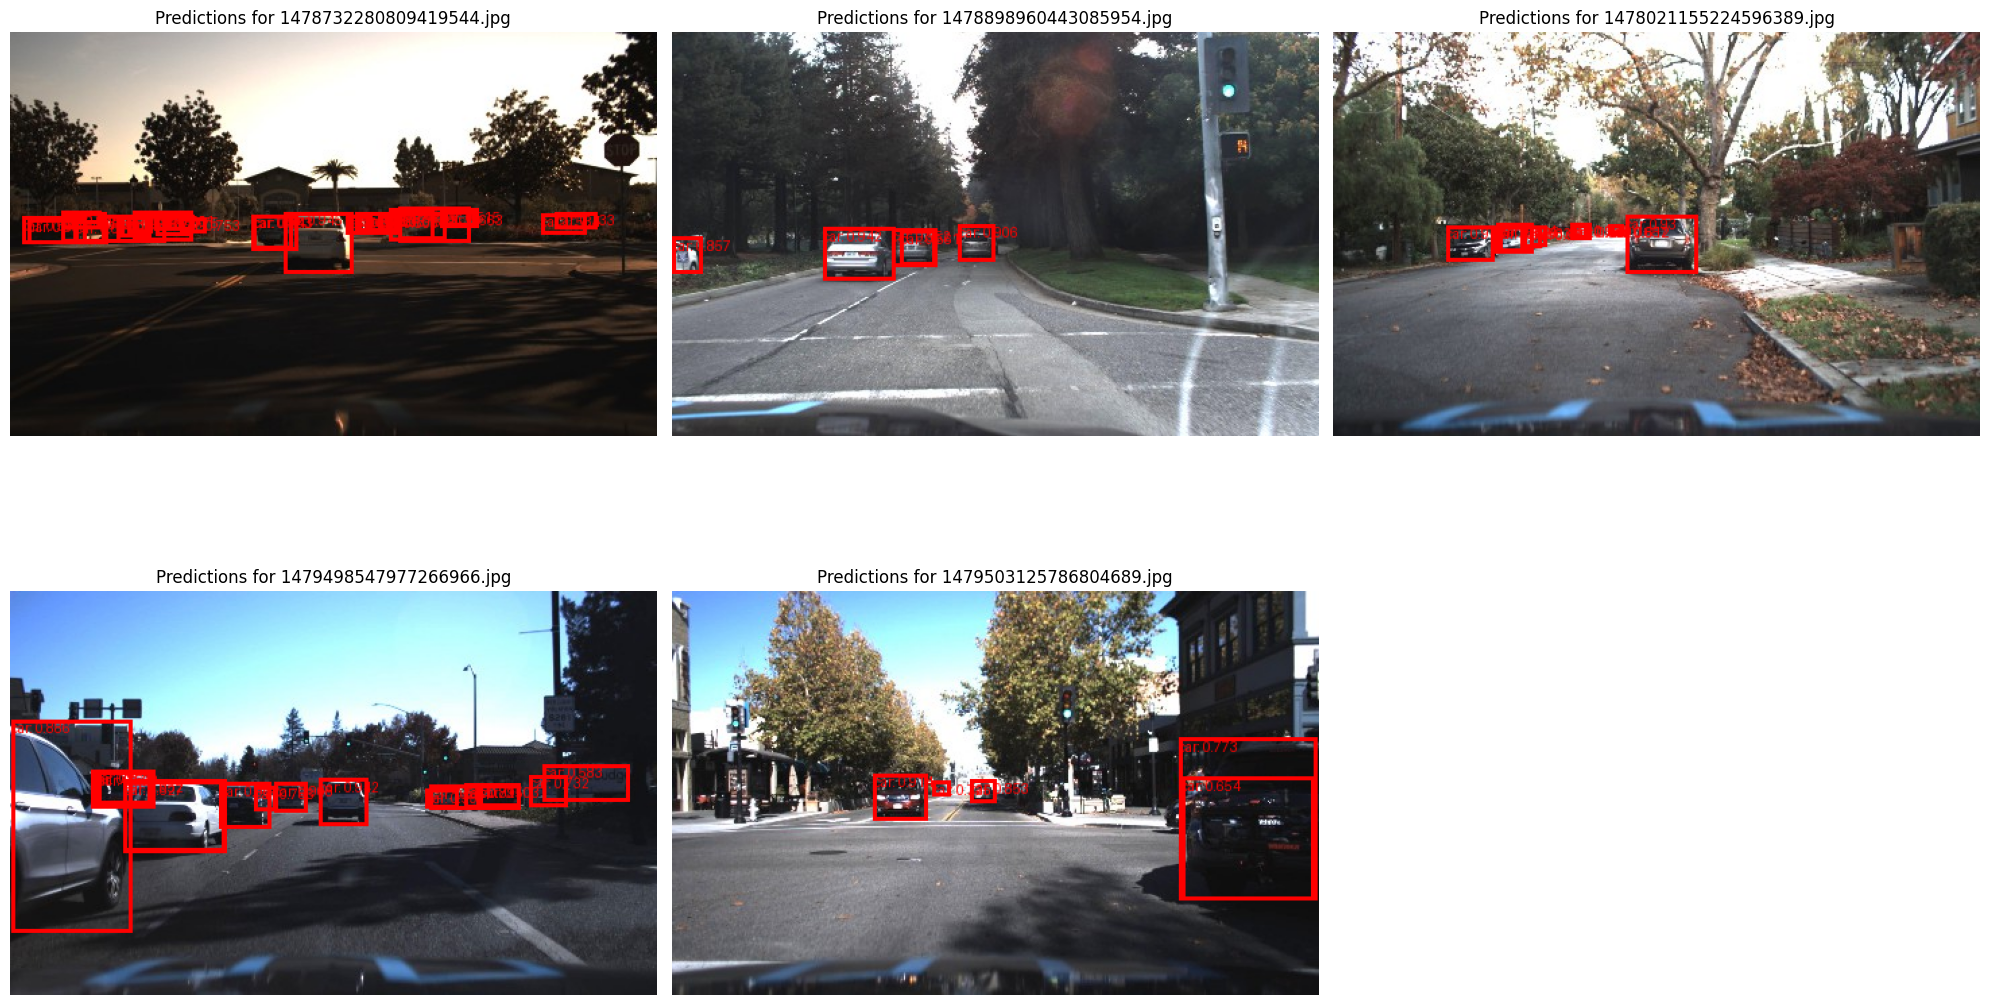


Training and evaluation complete!
Model saved to: ./yolos_driving_detection/final_model
Prediction samples saved to: prediction_samples.png


In [16]:
# Main training block - required for Windows multiprocessing
if __name__ == "__main__":
    # Training Arguments - Optimized for RTX 4090
    training_args = TrainingArguments(
        output_dir="./yolos_driving_detection",
        num_train_epochs=1,
        per_device_train_batch_size=64,
        per_device_eval_batch_size=64,
        gradient_accumulation_steps=1,  # Increase if OOM occurs
        learning_rate=5e-5,
        weight_decay=0.01,
        warmup_steps=500,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="loss",
        logging_dir="./logs",
        logging_steps=50,
        save_total_limit=3,
        remove_unused_columns=False,
        push_to_hub=False,
        dataloader_num_workers=0,  # Set to 0 for Windows compatibility
        # Performance optimizations for RTX 4090
        bf16=True,  # Use BF16 instead of FP16 for better stability on 4090
        tf32=True,  # Enable TF32 for better performance on Ampere+ GPUs
        dataloader_pin_memory=True,  # Pin memory for faster GPU transfer
        gradient_checkpointing=False,  # Disable for speed (enable if OOM)
        optim="adamw_torch_fused",  # Fused AdamW for faster optimizer steps
        # Additional speedups
        ddp_find_unused_parameters=False,
        auto_find_batch_size=True,  # Set to True to auto-find optimal batch size
        seed=SEED,
    )

    # Initialize Trainer
    print("\nInitializing Trainer...")
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        data_collator=collate_fn,
        tokenizer=processor,
    )

    # Train the model
    print("\nStarting training...")
    print("=" * 50)
    trainer.train()

    # Save the final model
    print("\nSaving final model...")
    model.save_pretrained("./yolos_driving_detection/final_model")
    processor.save_pretrained("./yolos_driving_detection/final_model")

    # Evaluation on test set
    print("\n" + "=" * 50)
    print("Evaluating on test set...")
    test_results = trainer.evaluate(test_dataset)
    print("\nTest Results:")
    for key, value in test_results.items():
        print(f"{key}: {value}")

    # Visualize some predictions from test set
    print("\n" + "=" * 50)
    print("Generating prediction visualizations...")

    # Get some test images
    test_indices = random.sample(range(len(test_dataset)), min(5, len(test_dataset)))

    plt.figure(figsize=(20, 12))
    for i, idx in enumerate(test_indices):
        # Get original image path
        original_idx = test_dataset.indices[idx]
        image_id = full_dataset.image_ids[original_idx]
        img_path = os.path.join(image_dir, image_id)

        # Visualize
        pred_image = visualize_predictions(img_path, model, processor, threshold=0.5)

        plt.subplot(2, 3, i + 1)
        plt.imshow(pred_image)
        plt.title(f"Predictions for {image_id}")
        plt.axis("off")

    plt.tight_layout()
    plt.savefig("prediction_samples.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("\nTraining and evaluation complete!")
    print("Model saved to: ./yolos_driving_detection/final_model")
    print("Prediction samples saved to: prediction_samples.png")